<a href="https://colab.research.google.com/github/victormaciase/EconometriaFinanciera_MagisterFinanzasWK/blob/main/Lab1/Lab1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Laboratorio 1

In [26]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [27]:
url_data = "https://raw.githubusercontent.com/victormaciase/EconometriaFinanciera_MagisterFinanzasWK/refs/heads/main/Lab1/anscombe.csv"

In [28]:
# Leer el archivo CSV directamente desde internet
df = pd.read_csv(url_data, index_col='rownames')

In [29]:
# Revisar que todo se haya cargado correctamente
print("Estructura de la base de datos:")
print(df.info())

Estructura de la base de datos:
<class 'pandas.core.frame.DataFrame'>
Index: 11 entries, 1 to 11
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   x1      11 non-null     int64  
 1   x2      11 non-null     int64  
 2   x3      11 non-null     int64  
 3   x4      11 non-null     int64  
 4   y1      11 non-null     float64
 5   y2      11 non-null     float64
 6   y3      11 non-null     float64
 7   y4      11 non-null     float64
dtypes: float64(4), int64(4)
memory usage: 792.0 bytes
None


In [30]:
print("Datos del Cuarteto de Anscombe cargados:")
print(df)

Datos del Cuarteto de Anscombe cargados:
          x1  x2  x3  x4     y1    y2     y3     y4
rownames                                           
1         10  10  10   8   8.04  9.14   7.46   6.58
2          8   8   8   8   6.95  8.14   6.77   5.76
3         13  13  13   8   7.58  8.74  12.74   7.71
4          9   9   9   8   8.81  8.77   7.11   8.84
5         11  11  11   8   8.33  9.26   7.81   8.47
6         14  14  14   8   9.96  8.10   8.84   7.04
7          6   6   6   8   7.24  6.13   6.08   5.25
8          4   4   4  19   4.26  3.10   5.39  12.50
9         12  12  12   8  10.84  9.13   8.15   5.56
10         7   7   7   8   4.82  7.26   6.42   7.91
11         5   5   5   8   5.68  4.74   5.73   6.89


# Estadística descriptiva

A continuación se presenta la media artimética, desviación estándar, percentiles 25, 50 y 75 y los valores mínimos y máximos de cada variable.

In [31]:
# Calcular estadísticas descriptivas básicas de todo el DataFrame
estadistica_descriptiva = df.describe()

In [32]:
print(estadistica_descriptiva)

              x1         x2         x3         x4         y1         y2  \
count  11.000000  11.000000  11.000000  11.000000  11.000000  11.000000   
mean    9.000000   9.000000   9.000000   9.000000   7.500909   7.500909   
std     3.316625   3.316625   3.316625   3.316625   2.031568   2.031657   
min     4.000000   4.000000   4.000000   8.000000   4.260000   3.100000   
25%     6.500000   6.500000   6.500000   8.000000   6.315000   6.695000   
50%     9.000000   9.000000   9.000000   8.000000   7.580000   8.140000   
75%    11.500000  11.500000  11.500000   8.000000   8.570000   8.950000   
max    14.000000  14.000000  14.000000  19.000000  10.840000   9.260000   

              y3         y4  
count  11.000000  11.000000  
mean    7.500000   7.500909  
std     2.030424   2.030579  
min     5.390000   5.250000  
25%     6.250000   6.170000  
50%     7.110000   7.040000  
75%     7.980000   8.190000  
max    12.740000  12.500000  


In [33]:
# Mostrar sólo la media aritmética y desviación estándar
print(estadistica_descriptiva.loc[['mean', 'std']])

            x1        x2        x3        x4        y1        y2        y3  \
mean  9.000000  9.000000  9.000000  9.000000  7.500909  7.500909  7.500000   
std   3.316625  3.316625  3.316625  3.316625  2.031568  2.031657  2.030424   

            y4  
mean  7.500909  
std   2.030579  


La matriz de correlaciones es la siguiente:

In [34]:
# Calcular la matriz completa de correlación
matriz_corr = df.corr()

In [35]:
print(matriz_corr)

          x1        x2        x3        x4        y1        y2        y3  \
x1  1.000000  1.000000  1.000000 -0.500000  0.816421  0.816237  0.816287   
x2  1.000000  1.000000  1.000000 -0.500000  0.816421  0.816237  0.816287   
x3  1.000000  1.000000  1.000000 -0.500000  0.816421  0.816237  0.816287   
x4 -0.500000 -0.500000 -0.500000  1.000000 -0.529093 -0.718437 -0.344661   
y1  0.816421  0.816421  0.816421 -0.529093  1.000000  0.750005  0.468717   
y2  0.816237  0.816237  0.816237 -0.718437  0.750005  1.000000  0.587919   
y3  0.816287  0.816287  0.816287 -0.344661  0.468717  0.587919  1.000000   
y4 -0.314047 -0.314047 -0.314047  0.816521 -0.489116 -0.478095 -0.155472   

          y4  
x1 -0.314047  
x2 -0.314047  
x3 -0.314047  
x4  0.816521  
y1 -0.489116  
y2 -0.478095  
y3 -0.155472  
y4  1.000000  


# Gráficos

A continuación se presentan 4 gráficos de dispersión (`scatterplot`) que muestra la relación entre las variables:

In [39]:
# Configurar el estilo visual de Seaborn
sns.set_theme(style="ticks")


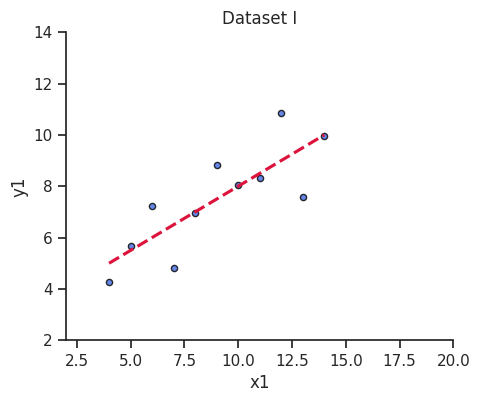

In [47]:
# Graficar cada uno por separado forzando su propia figura independiente
# Esto evita el conflicto de la cuadrícula compartida en Colab

# --- Dataset I ---
plt.figure(figsize=(5, 4))
sns.regplot(data=df, x='x1', y='y1', ci=None,
            scatter_kws={"s": 20, "color": "royalblue", "edgecolor": "black"},
            line_kws={"color": "crimson", "linestyle": "--"})
plt.title('Dataset I')
plt.xlim(2, 20); plt.ylim(2, 14)
sns.despine()
plt.show() # <--- Esto obliga a Colab a renderizar este gráfico antes de pasar al siguiente

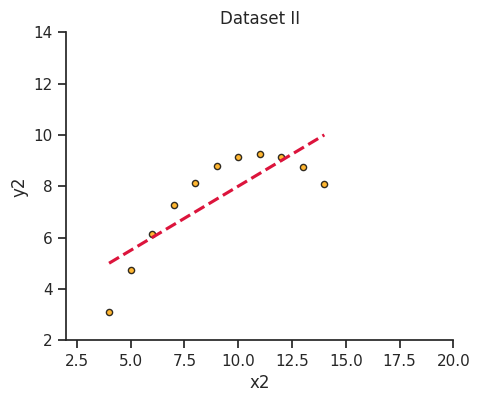

In [46]:
# --- Dataset II ---
plt.figure(figsize=(5, 4))
sns.regplot(data=df, x='x2', y='y2', ci=None,
            scatter_kws={"s": 20, "color": "orange", "edgecolor": "black"},
            line_kws={"color": "crimson", "linestyle": "--"})
plt.title('Dataset II')
plt.xlim(2, 20); plt.ylim(2, 14)
sns.despine()
plt.show()

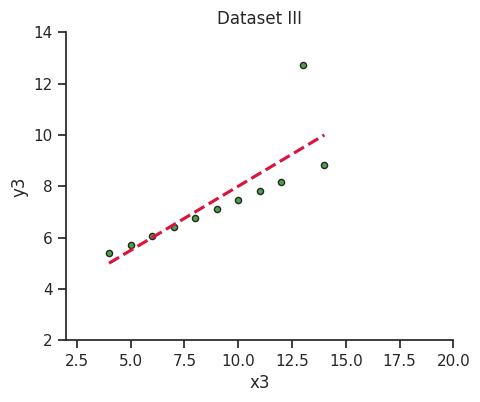

In [48]:
# --- Dataset III ---
plt.figure(figsize=(5, 4))
sns.regplot(data=df, x='x3', y='y3', ci=None,
            scatter_kws={"s": 20, "color": "forestgreen", "edgecolor": "black"},
            line_kws={"color": "crimson", "linestyle": "--"})
plt.title('Dataset III')
plt.xlim(2, 20); plt.ylim(2, 14)
sns.despine()
plt.show()

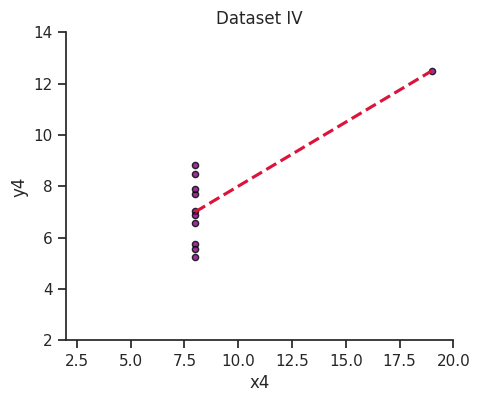

In [49]:
# --- Dataset IV ---
plt.figure(figsize=(5, 4))
sns.regplot(data=df, x='x4', y='y4', ci=None,
            scatter_kws={"s": 20, "color": "purple", "edgecolor": "black"},
            line_kws={"color": "crimson", "linestyle": "--"})
plt.title('Dataset IV')
plt.xlim(2, 20); plt.ylim(2, 14)
sns.despine()
plt.show()